In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

URL = "https://github.com/cfneves/turma-visualizacao-de-dados/raw/refs/heads/master/alunos/anaysa_lopes/semana_04/bases/base_rh.xlsx"
df = pd.read_excel(URL)

salarios = df["Salario"].to_numpy()
idades = df["Idade"].to_numpy()

In [2]:
## 1. Extraia como arrays NumPy as colunas `Salario` e `Idade`. Mostre `shape`, `dtype`, `min()` e `max()` de cada um.

print(f"Salários - Shape: {salarios.shape}, Dtype: {salarios.dtype}, Mínimo: {salarios.min()}, Máximo: {salarios.max()}")
print(f"Idades - Shape: {idades.shape}, Dtype: {idades.dtype}, Mínimo: {idades.min()}, Máximo: {idades.max()}")


Salários - Shape: (1000,), Dtype: float64, Mínimo: 2000.71, Máximo: 14954.51
Idades - Shape: (1000,), Dtype: int64, Mínimo: 18, Máximo: 65


In [5]:
## 2. Calcule **sem loop**: média, mediana, desvio padrão e soma total dos salários. Compare com os valores do `df.describe()` — devem ser iguais.

print(f"Média: {salarios.mean()}")
print(f"Mediana: {np.median(salarios)}")
print(f"Desvio Padrão: {salarios.std()}")
print(f"Soma Total: {salarios.sum()}")

Média: 8579.951780000001
Mediana: 8571.134999999998
Desvio Padrão: 3655.536167127366
Soma Total: 8579951.780000001


In [7]:
## 3. Slicing: selecione os 10 maiores salários usando `np.argsort()`. Exiba os valores.

indices_ordenados = np.argsort(salarios)
dez_maiores = salarios[indices_ordenados[-10:]][::-1]

valores_formatados = ", ".join([f"R$ {s:,.2f}" for s in dez_maiores])
print(valores_formatados)

R$ 14,954.51, R$ 14,951.53, R$ 14,948.18, R$ 14,942.48, R$ 14,942.39, R$ 14,923.61, R$ 14,918.19, R$ 14,914.63, R$ 14,912.48, R$ 14,904.99


In [10]:
# #4. Use `np.where()` para criar o array `geração`:
#    - `"Boomer"` se Idade >= 60
#    - `"Gen X"` se Idade >= 44
#    - `"Millennial"` se Idade >= 28
#    - `"Gen Z"` se Idade < 28
#    *(Use `np.select()` com as quatro condições.)* 

conds = [
    idades >= 60,
    idades >= 44,
    idades >= 28,
]
cats = ["Boomer", "Gen X", "Millennial"]
geracao = np.select(conds, cats, default="Gen Z")


In [11]:
## 5. Use máscara booleana (sem groupby) para calcular o salário médio de cada geração.

geracoes = ["Boomer", "Gen X", "Millennial", "Gen Z"]
for g in geracoes:
    mask = geracao == g
    media = salarios[mask].mean()
    print(f"{g:12s}: R$ {media:,.2f}  (n={mask.sum()})")


Boomer      : R$ 8,223.51  (n=112)
Gen X       : R$ 8,458.02  (n=333)
Millennial  : R$ 8,814.86  (n=362)
Gen Z       : R$ 8,556.57  (n=193)


In [13]:
## 6. Broadcasting: crie o array `salario_normalizado` subtraindo a média e dividindo pelo desvio padrão (padronização z-score). Verifique que a média resultante é ~0 e o desvio é ~1.

salario_normalizado = (salarios - salarios.mean()) / salarios.std()
print(f"Média após normalização : {salario_normalizado.mean():.6f}")
print(f"Desvio após normalização: {salario_normalizado.std():.6f}")

Média após normalização : -0.000000
Desvio após normalização: 1.000000


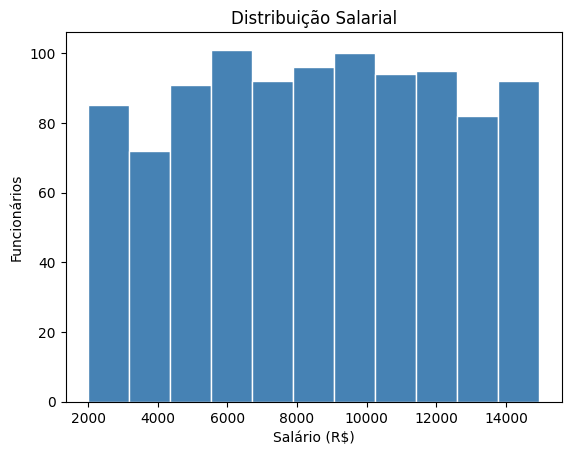

In [14]:
## 7. Gráfico 1 — histograma dos salários com `bins = np.linspace(salarios.min(), salarios.max(), 12)`.

bins = np.linspace(salarios.min(), salarios.max(), 12)
plt.hist(salarios, bins=bins, color="steelblue", edgecolor="white")
plt.title("Distribuição Salarial")
plt.xlabel("Salário (R$)")
plt.ylabel("Funcionários")
plt.show()

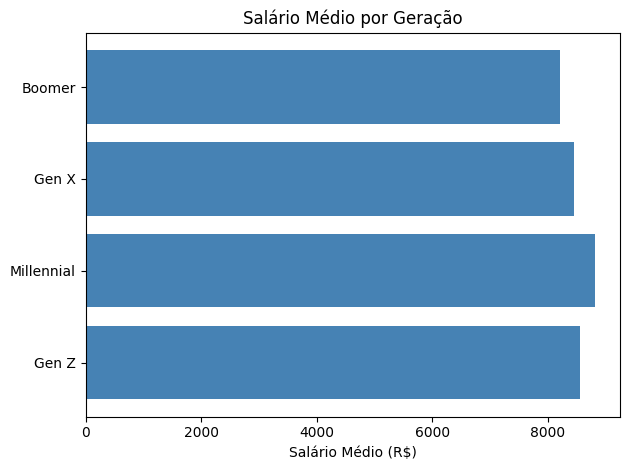

In [15]:
#8. Gráfico 2 — barras horizontais com o salário médio de cada geração calculado no passo 5.

medias_ger = np.array([salarios[geracao == g].mean() for g in geracoes])
plt.barh(geracoes, medias_ger, color="steelblue")
plt.title("Salário Médio por Geração")
plt.xlabel("Salário Médio (R$)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()